<a href="https://www.kaggle.com/code/aamir28/great-american-coffee-taste-test?scriptVersionId=330028384" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# ☕ Cupping Lab Report — National Coffee Taste Test, Survey Analysis

**Analyst:** Muhammad Aamir
**Sample:** 4,042 respondents · 57 fields · blind 4-coffee taste test (Coffee A–D) + drinking habits, spend, and demographics
**Format:** Specialty-coffee quality-control / cupping-lab report

---

### Lab Notes
This dataset comes from a public coffee-drinking survey paired with a **blind taste test**: each respondent rated four unlabeled coffees (`A`, `B`, `C`, `D`) on **bitterness**, **acidity**, and **personal preference**, each on a 1–5 scale, alongside everyday brewing habits, spend, and demographics.

This report runs the data through a full quality-control pass — completeness check, calibration of the panel (taster expertise), the blind-cupping scoresheet itself, behavioral and spend analysis, and a closing tasting summary — exactly as a coffee lab would QC a batch of cupping scores before publishing them.



## 🧪 Lab Setup — Imports & Style

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.patches import FancyBboxPatch
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 140)

# --- Cupping Lab palette: parchment background, espresso browns, roast ambers ---
PARCHMENT   = "#F4EDE1"
PARCHMENT_2 = "#EFE5D2"
ESPRESSO    = "#3B2418"
ESPRESSO_2  = "#5C3A26"
ROAST_AMBER = "#B5651D"
ROAST_GOLD  = "#C68642"
CREMA       = "#E8C39E"
ACID_TEAL   = "#3E6259"     # used sparingly for acidity-related charts
INK         = "#2B1B12"
GRID        = "#D9C9AE"

COFFEE_COLORS = {
    "Coffee A": "#8B5E34",
    "Coffee B": "#B5651D",
    "Coffee C": "#6F4E37",
    "Coffee D": "#C68642",
}

plt.rcParams.update({
    "figure.facecolor": PARCHMENT,
    "axes.facecolor": PARCHMENT_2,
    "axes.edgecolor": ESPRESSO,
    "axes.labelcolor": INK,
    "text.color": INK,
    "xtick.color": INK,
    "ytick.color": INK,
    "axes.titlecolor": ESPRESSO,
    "axes.titleweight": "bold",
    "axes.titlesize": 13,
    "axes.labelsize": 10.5,
    "font.family": "monospace",
    "grid.color": GRID,
    "grid.linewidth": 0.6,
    "axes.grid": True,
    "axes.grid.axis": "y",
    "axes.linewidth": 1.1,
    "savefig.facecolor": PARCHMENT,
})

def lab_title(ax, code_tag, title):
    # Cupping-sheet style title: a monospace lab code tag + the descriptive title.
    ax.set_title(f"[{code_tag}]  {title}", loc="left", fontsize=12.5, fontweight="bold", color=ESPRESSO, pad=10)

def stamp(ax, text, loc="lower right"):
    # Small QC 'stamp' annotation in the corner of a chart.
    positions = {
        "lower right": (0.985, 0.03, "right", "bottom"),
        "upper right": (0.985, 0.95, "right", "top"),
    }
    x, y, ha, va = positions.get(loc, positions["lower right"])
    ax.text(x, y, text, transform=ax.transAxes, ha=ha, va=va,
             fontsize=8, color=ESPRESSO_2, style="italic", alpha=0.8)

print("Lab instruments calibrated. Palette and style loaded.")


Lab instruments calibrated. Palette and style loaded.


## 📋 Sample Intake — Load & Inventory

In [2]:
df = pd.read_csv("/kaggle/input/datasets/ibrahimqasimi/great-american-coffee-taste-test-2024/24_Coffee_Taste_Test.csv")

print(f"Sample size: {df.shape[0]:,} respondents")
print(f"Fields collected: {df.shape[1]}")
df.head()


Sample size: 4,042 respondents
Fields collected: 57


,submission_id,age,cups,where_drink,brew,brew_other,purchase,purchase_other,favorite,favorite_specify,additions,additions_other,dairy,sweetener,style,strength,roast_level,caffeine,expertise,coffee_a_bitterness,coffee_a_acidity,coffee_a_personal_preference,coffee_a_notes,coffee_b_bitterness,coffee_b_acidity,coffee_b_personal_preference,coffee_b_notes,coffee_c_bitterness,coffee_c_acidity,coffee_c_personal_preference,coffee_c_notes,coffee_d_bitterness,coffee_d_acidity,coffee_d_personal_preference,coffee_d_notes,prefer_abc,prefer_ad,prefer_overall,wfh,total_spend,why_drink,why_drink_other,taste,know_source,most_paid,most_willing,value_cafe,spent_equipment,value_equipment,gender,gender_specify,education_level,ethnicity_race,ethnicity_race_specify,employment_status,number_children,political_affiliation
0,gMR29l,18-24 years old,NaN,NaN,NaN,NaN,NaN,NaN,Regular drip coffee,NaN,No - just black,NaN,NaN,NaN,Complex,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,BkPN0e,25-34 years old,NaN,NaN,Pod/capsule machine (e.g. Keurig/Nespresso),NaN,NaN,NaN,Iced coffee,NaN,"Sugar or sweetener, No - just black",NaN,NaN,NaN,Light,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,W5G8jj,25-34 years old,NaN,NaN,Bean-to-cup machine,NaN,NaN,NaN,Regular drip coffee,NaN,No - just black,NaN,NaN,NaN,Complex,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,4xWgGr,35-44 years old,NaN,NaN,Coffee brewing machine (e.g. Mr. Coffee),NaN,NaN,NaN,Iced coffee,NaN,"No - just black, Cinnamon",NaN,NaN,NaN,Complex,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,QD27Q8,25-34 years old,NaN,NaN,Pour over,NaN,NaN,NaN,Latte,NaN,No - just black,NaN,NaN,NaN,Sweet,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
print("Column inventory:\n")
for c in df.columns:
    print(f"  {c}")

Column inventory:

  submission_id
  age
  cups
  where_drink
  brew
  brew_other
  purchase
  purchase_other
  favorite
  favorite_specify
  additions
  additions_other
  dairy
  sweetener
  style
  strength
  roast_level
  caffeine
  expertise
  coffee_a_bitterness
  coffee_a_acidity
  coffee_a_personal_preference
  coffee_a_notes
  coffee_b_bitterness
  coffee_b_acidity
  coffee_b_personal_preference
  coffee_b_notes
  coffee_c_bitterness
  coffee_c_acidity
  coffee_c_personal_preference
  coffee_c_notes
  coffee_d_bitterness
  coffee_d_acidity
  coffee_d_personal_preference
  coffee_d_notes
  prefer_abc
  prefer_ad
  prefer_overall
  wfh
  total_spend
  why_drink
  why_drink_other
  taste
  know_source
  most_paid
  most_willing
  value_cafe
  spent_equipment
  value_equipment
  gender
  gender_specify
  education_level
  ethnicity_race
  ethnicity_race_specify
  employment_status
  number_children
  political_affiliation


In [4]:
missing = df.isna().sum().sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(1)
intake_report = pd.DataFrame({"missing_count": missing, "missing_pct": missing_pct})
intake_report.head(20)

,missing_count,missing_pct
gender_specify,4030,99.7
purchase_other,4011,99.2
additions_other,3994,98.8
ethnicity_race_specify,3937,97.4
favorite_specify,3928,97.2
why_drink_other,3875,95.9
sweetener,3530,87.3
brew_other,3364,83.2
purchase,3332,82.4
number_children,3186,78.8


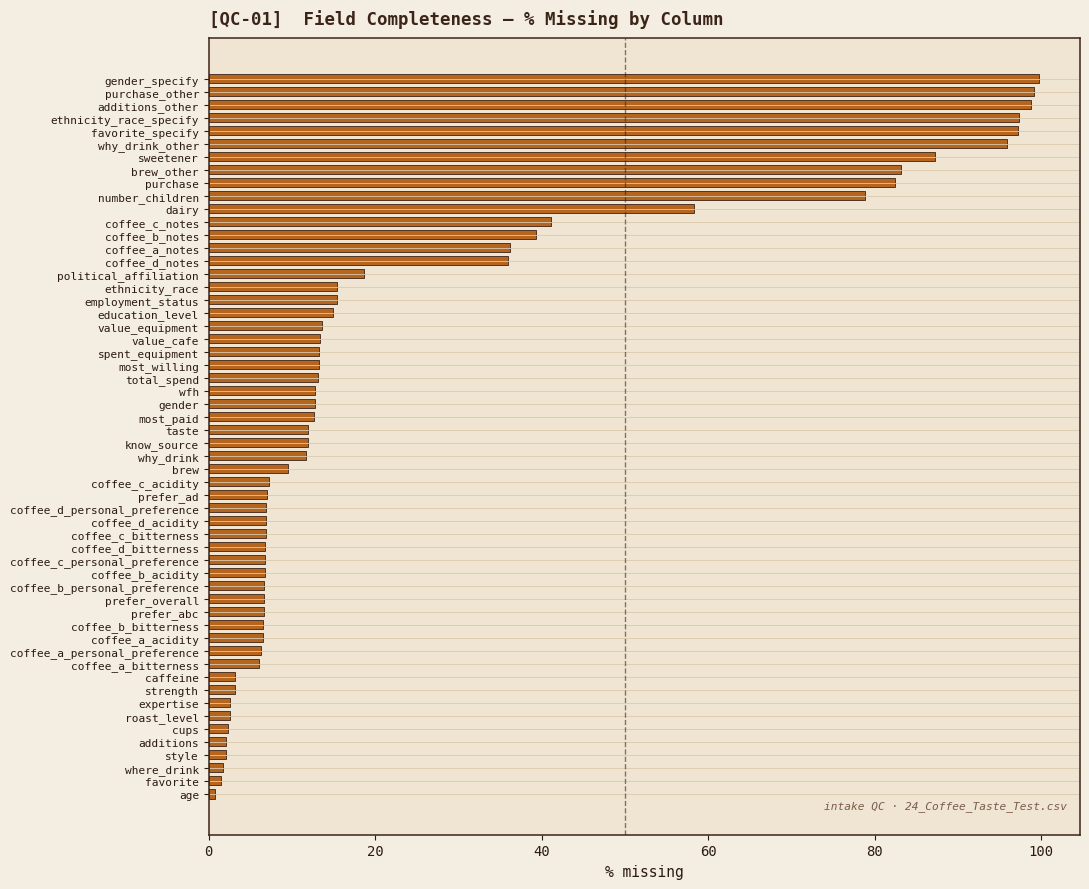

In [5]:
fig, ax = plt.subplots(figsize=(11, 9))
top_missing = missing_pct[missing_pct > 0].sort_values()
bars = ax.barh(top_missing.index, top_missing.values, color=ROAST_AMBER, edgecolor=ESPRESSO, linewidth=0.6, height=0.7)
ax.axvline(50, color=ESPRESSO, linestyle="--", linewidth=1, alpha=0.6)
lab_title(ax, "QC-01", "Field Completeness — % Missing by Column")
ax.set_xlabel("% missing")
ax.tick_params(axis='y', labelsize=8)
stamp(ax, "intake QC · 24_Coffee_Taste_Test.csv")
plt.tight_layout()
plt.show()


**Intake reading:** the taste-test rating columns (`coffee_a/b/c/d_*`) carry the highest missingness — expected, since not every respondent who started the survey finished all four blind tastings. Demographic and habit fields are far more complete. We'll treat each analysis block independently and drop rows only where the *specific* fields in use are missing (not globally), to avoid discarding usable data.

## 🎚️ Panel Calibration — Who's on the Tasting Panel?

Before trusting any cupping scores, a lab calibrates its panel. Here we profile *who* is doing the tasting: age, self-rated expertise, and daily coffee habits.

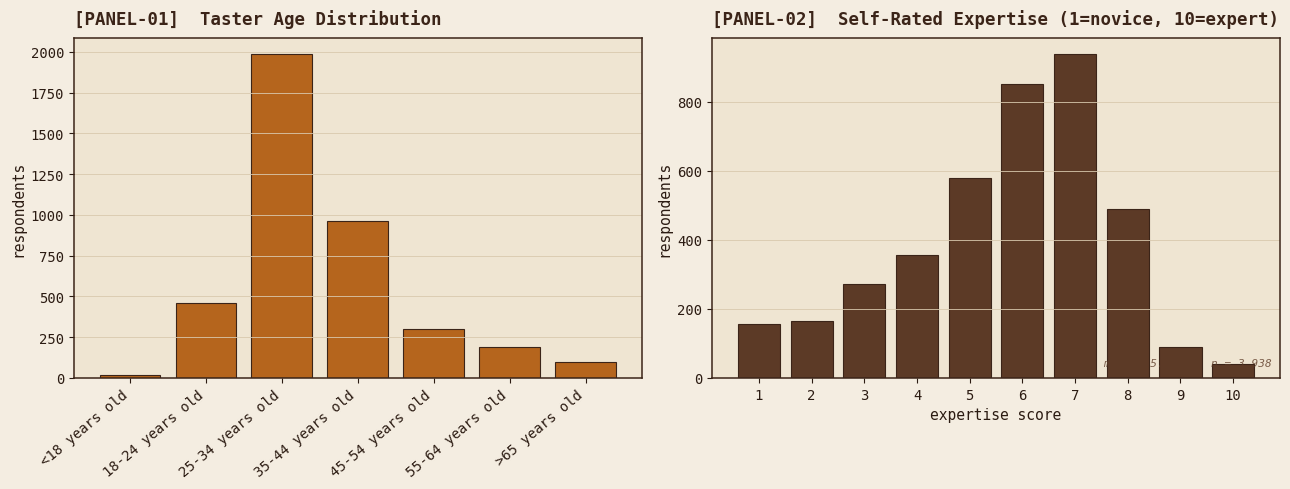

Median self-rated expertise: 6 / 10
Share rating themselves 7+: 38.5%


In [6]:
age_order = ["<18 years old", "18-24 years old", "25-34 years old", "35-44 years old",
             "45-54 years old", "55-64 years old", ">65 years old"]
age_counts = df['age'].value_counts().reindex(age_order).fillna(0)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].bar(age_counts.index, age_counts.values, color=ROAST_AMBER, edgecolor=ESPRESSO, linewidth=0.8)
lab_title(axes[0], "PANEL-01", "Taster Age Distribution")
axes[0].set_ylabel("respondents")
axes[0].tick_params(axis='x', rotation=40)
for label in axes[0].get_xticklabels():
    label.set_ha("right")

expertise_counts = df['expertise'].value_counts().sort_index()
axes[1].bar(expertise_counts.index.astype(int), expertise_counts.values, color=ESPRESSO_2, edgecolor=ESPRESSO, linewidth=0.8)
lab_title(axes[1], "PANEL-02", "Self-Rated Expertise (1=novice, 10=expert)")
axes[1].set_xlabel("expertise score")
axes[1].set_ylabel("respondents")
axes[1].set_xticks(range(1, 11))

stamp(axes[1], f"mean = {df['expertise'].mean():.2f}  ·  n = {df['expertise'].notna().sum():,}")
plt.tight_layout()
plt.show()

print(f"Median self-rated expertise: {df['expertise'].median():.0f} / 10")
print(f"Share rating themselves 7+: {(df['expertise'] >= 7).mean()*100:.1f}%")


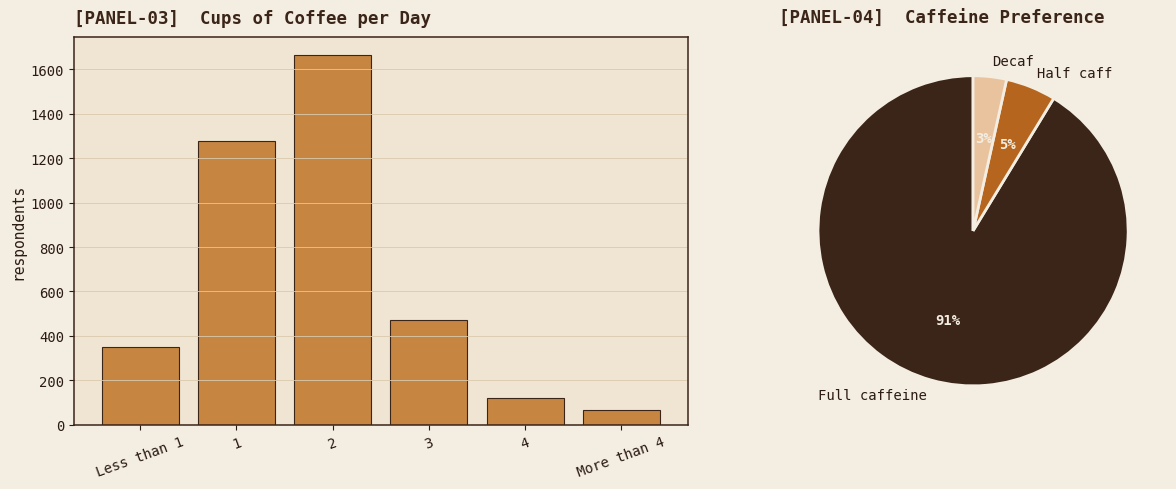

In [7]:
cups_order = ["Less than 1", "1", "2", "3", "4", "More than 4"]
cups_counts = df['cups'].value_counts().reindex(cups_order).fillna(0)

caff_counts = df['caffeine'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].bar(cups_counts.index, cups_counts.values, color=ROAST_GOLD, edgecolor=ESPRESSO, linewidth=0.8)
lab_title(axes[0], "PANEL-03", "Cups of Coffee per Day")
axes[0].set_ylabel("respondents")
axes[0].tick_params(axis='x', rotation=20)

wedges, _, autotexts = axes[1].pie(
    caff_counts.values, labels=caff_counts.index, autopct="%1.0f%%",
    colors=[ESPRESSO, ROAST_AMBER, CREMA], startangle=90,
    wedgeprops=dict(edgecolor=PARCHMENT, linewidth=2),
    textprops=dict(color=INK, fontsize=10),
)
for t in autotexts:
    t.set_color(PARCHMENT)
    t.set_fontweight("bold")
axes[1].set_title("[PANEL-04]  Caffeine Preference", loc="left", fontsize=12.5, fontweight="bold", color=ESPRESSO, pad=10)

plt.tight_layout()
plt.show()


**Calibration reading:** the panel skews toward self-described moderate-to-experienced drinkers (median expertise 6/10), drinking 1–2 cups a day, and overwhelmingly favoring full-caffeine coffee. This is a panel of regular, engaged coffee drinkers rather than casual sippers — a reasonably reliable group for cupping data.

## 🫘 The Blind Cupping Scoresheet — Coffee A vs. B vs. C vs. D

This is the heart of the lab report: four unlabeled coffees, each scored 1–5 on **bitterness**, **acidity**, and **personal preference** by every taster in the panel.

In [8]:
coffees = ["A", "B", "C", "D"]
metrics = ["bitterness", "acidity", "personal_preference"]

score_summary = pd.DataFrame(index=[f"Coffee {c}" for c in coffees])
for m in metrics:
    score_summary[m.replace("_", " ")] = [df[f"coffee_{c.lower()}_{m}"].mean() for c in coffees]
    score_summary[f"{m} n"] = [df[f"coffee_{c.lower()}_{m}"].notna().sum() for c in coffees]

score_summary.round(2)


,bitterness,bitterness n,acidity,acidity n,personal preference,personal_preference n
Coffee A,2.14,3798,3.63,3779,3.31,3789
Coffee B,3.01,3780,2.22,3767,3.07,3773
Coffee C,3.07,3764,2.37,3751,3.06,3766
Coffee D,2.16,3767,3.86,3765,3.38,3764


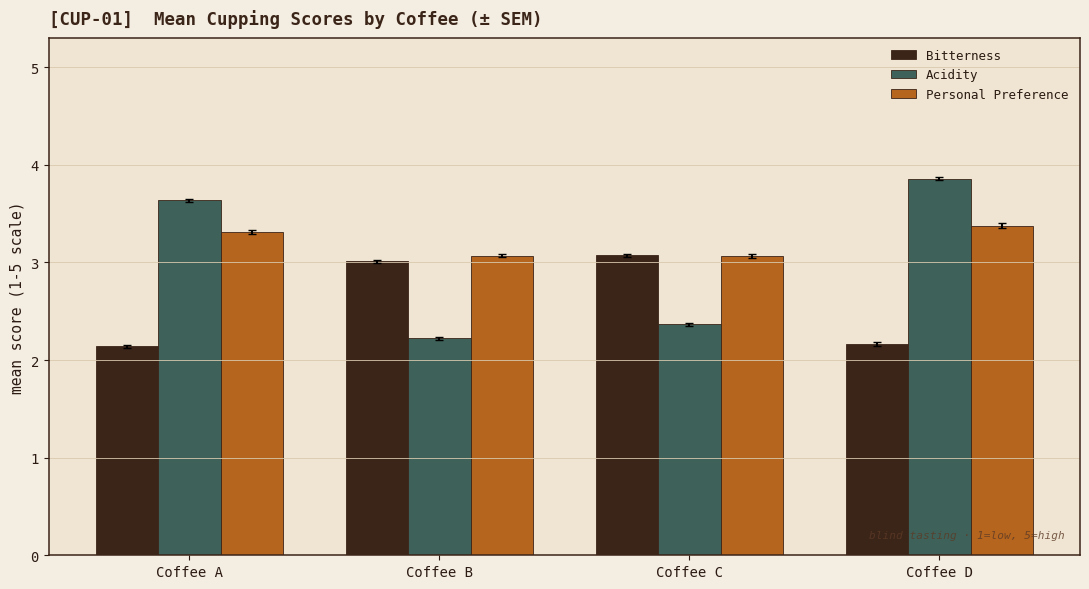

In [9]:
fig, ax = plt.subplots(figsize=(11, 6))
x = np.arange(len(coffees))
width = 0.25

bitter_means = [df[f"coffee_{c.lower()}_bitterness"].mean() for c in coffees]
acid_means   = [df[f"coffee_{c.lower()}_acidity"].mean() for c in coffees]
pref_means   = [df[f"coffee_{c.lower()}_personal_preference"].mean() for c in coffees]

bitter_sem = [df[f"coffee_{c.lower()}_bitterness"].sem() for c in coffees]
acid_sem   = [df[f"coffee_{c.lower()}_acidity"].sem() for c in coffees]
pref_sem   = [df[f"coffee_{c.lower()}_personal_preference"].sem() for c in coffees]

ax.bar(x - width, bitter_means, width, yerr=bitter_sem, capsize=3, label="Bitterness",
       color=ESPRESSO, edgecolor=ESPRESSO, linewidth=0.6)
ax.bar(x, acid_means, width, yerr=acid_sem, capsize=3, label="Acidity",
       color=ACID_TEAL, edgecolor=ESPRESSO, linewidth=0.6)
ax.bar(x + width, pref_means, width, yerr=pref_sem, capsize=3, label="Personal Preference",
       color=ROAST_AMBER, edgecolor=ESPRESSO, linewidth=0.6)

ax.set_xticks(x)
ax.set_xticklabels([f"Coffee {c}" for c in coffees])
ax.set_ylim(0, 5.3)
ax.set_ylabel("mean score (1-5 scale)")
lab_title(ax, "CUP-01", "Mean Cupping Scores by Coffee (± SEM)")
ax.legend(loc="upper right", frameon=False, fontsize=9)
stamp(ax, "blind tasting · 1=low, 5=high")
plt.tight_layout()
plt.show()


**Cupping note:** Coffees **A** and **D** read as the brighter, less bitter, higher-preference cups — while **B** and **C** show up as bitterer and lower-preference in the panel's blind scores. This split shows up consistently across all three measures, which is the kind of internal agreement a lab wants to see before trusting a result.

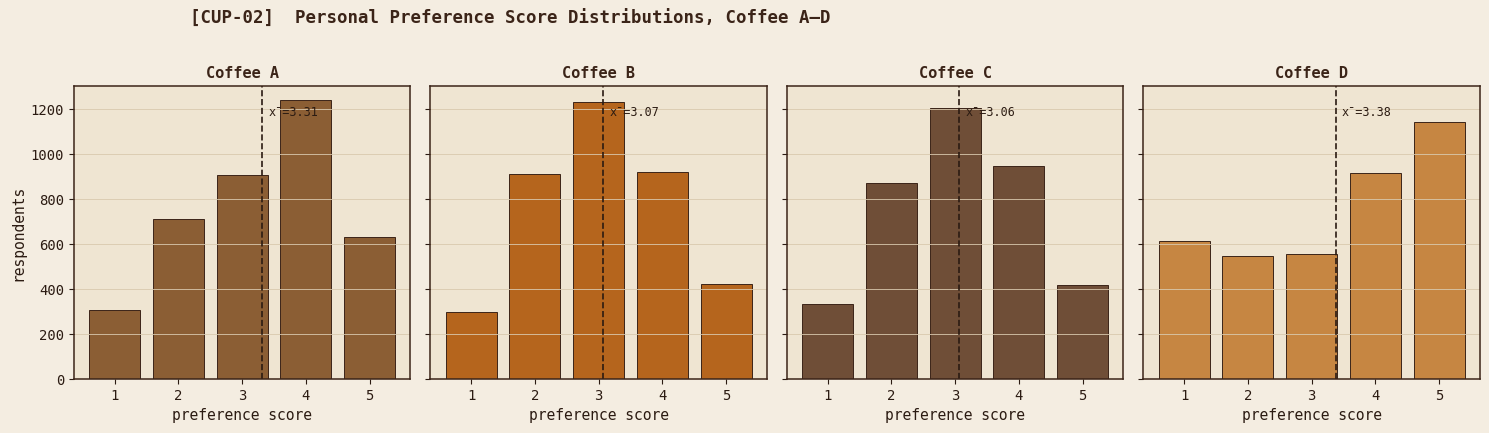

In [10]:
fig, axes = plt.subplots(1, 4, figsize=(15, 4.2), sharey=True)

for i, c in enumerate(coffees):
    ax = axes[i]
    col = f"coffee_{c.lower()}_personal_preference"
    vals = df[col].dropna()
    counts = vals.value_counts().reindex([1, 2, 3, 4, 5]).fillna(0)
    ax.bar(counts.index, counts.values, color=COFFEE_COLORS[f"Coffee {c}"], edgecolor=ESPRESSO, linewidth=0.7)
    ax.set_title(f"Coffee {c}", fontsize=11, color=ESPRESSO, fontweight="bold")
    ax.set_xticks([1, 2, 3, 4, 5])
    ax.set_xlabel("preference score")
    if i == 0:
        ax.set_ylabel("respondents")
    ax.axvline(vals.mean(), color=INK, linestyle="--", linewidth=1.2)
    ax.text(vals.mean() + 0.1, ax.get_ylim()[1]*0.9, f"x̄={vals.mean():.2f}", fontsize=8.5, color=INK)

fig.suptitle("[CUP-02]  Personal Preference Score Distributions, Coffee A–D", x=0.13, y=1.02,
             ha="left", fontsize=12.5, fontweight="bold", color=ESPRESSO)
plt.tight_layout()
plt.show()


## 🗺️ The Flavor Map — Bitterness vs. Acidity

Plotting each coffee's average bitterness against its average acidity gives a classic cupping "flavor map" — coffees that land in different quadrants taste structurally different to the panel, not just "better or worse."


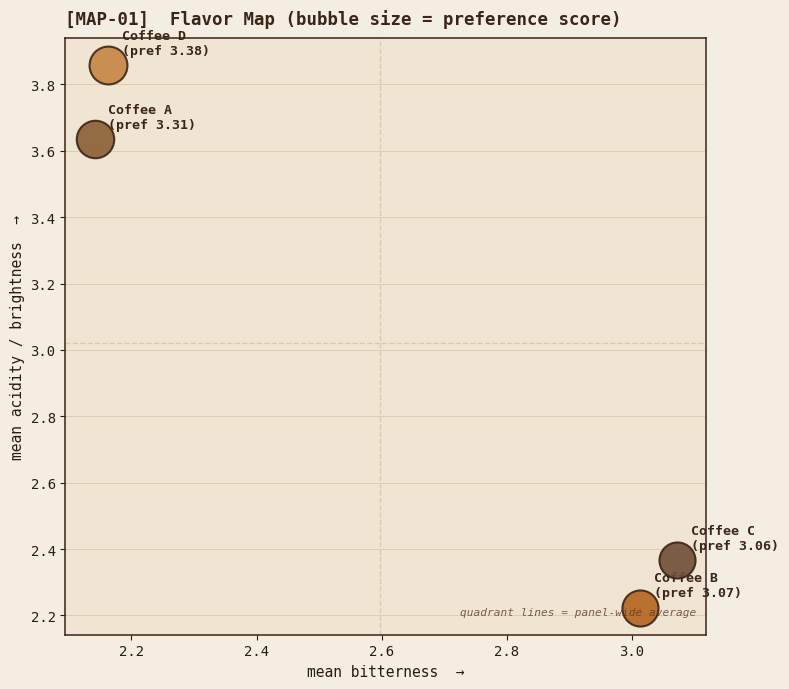

In [11]:
fig, ax = plt.subplots(figsize=(8, 7))

for c in coffees:
    bit = df[f"coffee_{c.lower()}_bitterness"].mean()
    acid = df[f"coffee_{c.lower()}_acidity"].mean()
    pref = df[f"coffee_{c.lower()}_personal_preference"].mean()
    ax.scatter(bit, acid, s=pref * 220, color=COFFEE_COLORS[f"Coffee {c}"],
               edgecolor=ESPRESSO, linewidth=1.5, zorder=3, alpha=0.9)
    ax.annotate(f"Coffee {c}\n(pref {pref:.2f})", (bit, acid), xytext=(10, 8), textcoords="offset points",
                fontsize=9.5, color=ESPRESSO, fontweight="bold")

mean_bit_all = np.mean([df[f"coffee_{c.lower()}_bitterness"].mean() for c in coffees])
mean_acid_all = np.mean([df[f"coffee_{c.lower()}_acidity"].mean() for c in coffees])
ax.axvline(mean_bit_all, color=GRID, linestyle="--", linewidth=1, zorder=1)
ax.axhline(mean_acid_all, color=GRID, linestyle="--", linewidth=1, zorder=1)

ax.set_xlabel("mean bitterness  →")
ax.set_ylabel("mean acidity / brightness  →")
lab_title(ax, "MAP-01", "Flavor Map (bubble size = preference score)")
stamp(ax, "quadrant lines = panel-wide average")
plt.tight_layout()
plt.show()


**Map reading:** Coffee **D** sits in the low-bitterness / high-acidity quadrant — the brightest, least bitter cup — and also pulls the top preference average. Coffee **B** sits opposite, more bitter and flatter on acidity, and scores lowest on preference. This is a coherent flavor story: in this panel, brighter and less bitter tracked with being better-liked, not the other way around.

## 🏆 The Verdict — Overall Preference Vote

Beyond the per-attribute scores, respondents were also asked to directly pick their favorite among the four (`prefer_overall`), plus head-to-head picks (`prefer_abc`, `prefer_ad`).

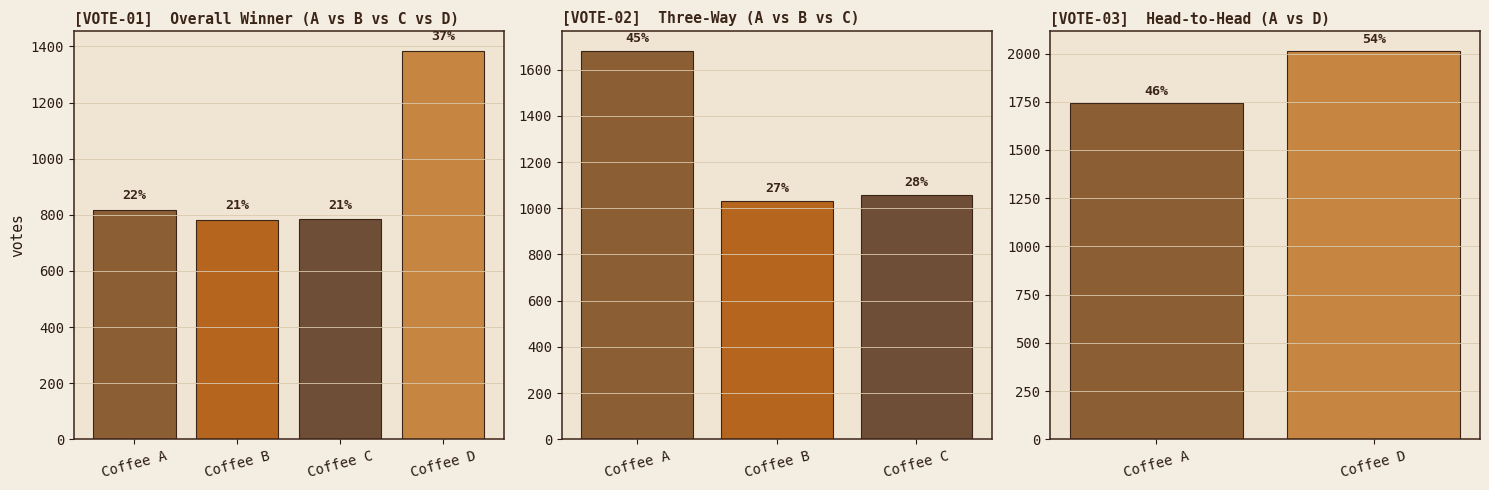

Overall winner vote counts:
prefer_overall
Coffee D    1385
Coffee A     818
Coffee C     784
Coffee B     783
Name: count, dtype: int64

Total votes cast: 3,770


In [12]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

vote_cols = ["prefer_overall", "prefer_abc", "prefer_ad"]
titles = ["Overall Winner (A vs B vs C vs D)", "Three-Way (A vs B vs C)", "Head-to-Head (A vs D)"]
tags = ["VOTE-01", "VOTE-02", "VOTE-03"]

for ax, col, title, tag in zip(axes, vote_cols, titles, tags):
    counts = df[col].value_counts()
    counts = counts.reindex(sorted(counts.index))
    colors = [COFFEE_COLORS.get(lbl, ROAST_AMBER) for lbl in counts.index]
    bars = ax.bar(counts.index, counts.values, color=colors, edgecolor=ESPRESSO, linewidth=0.8)
    total = counts.sum()
    for bar, val in zip(bars, counts.values):
        ax.text(bar.get_x() + bar.get_width()/2, val + total*0.01, f"{val/total*100:.0f}%",
                ha="center", fontsize=9.5, color=ESPRESSO, fontweight="bold")
    ax.set_title(f"[{tag}]  {title}", loc="left", fontsize=10.5, fontweight="bold", color=ESPRESSO)
    ax.set_ylabel("votes" if ax is axes[0] else "")
    ax.tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

print("Overall winner vote counts:")
print(df['prefer_overall'].value_counts())
print(f"\nTotal votes cast: {df['prefer_overall'].notna().sum():,}")


In [13]:
overall_votes = df['prefer_overall'].value_counts()
winner = overall_votes.idxmax()
winner_share = overall_votes.max() / overall_votes.sum() * 100
print(f"Panel's declared overall winner: {winner} ({winner_share:.1f}% of {overall_votes.sum():,} votes)")

# Cross-check: does the direct vote agree with the attribute-based preference scores?
pref_score_means = {f"Coffee {c}": df[f"coffee_{c.lower()}_personal_preference"].mean() for c in coffees}
score_winner = max(pref_score_means, key=pref_score_means.get)
print(f"Highest mean preference-score coffee: {score_winner} ({pref_score_means[score_winner]:.2f}/5)")
print(f"\nAgreement between direct vote and attribute scores: {'YES — consistent' if winner == score_winner else 'NO — these disagree'}")


Panel's declared overall winner: Coffee D (36.7% of 3,770 votes)
Highest mean preference-score coffee: Coffee D (3.38/5)

Agreement between direct vote and attribute scores: YES — consistent


## 🧰 Lab Instrument — Multi-Select Parser

Several survey fields allow multiple answers per respondent (e.g. "Where do you drink coffee?" → home *and* office *and* on the go). These arrive as comma-joined strings, and a few of the answer options *themselves* contain commas (e.g. *"Milk, dairy alternative, or coffee creamer"*), so a naive split would shred them. This helper protects known multi-word phrases before splitting.

In [14]:
def explode_multiselect(series, protected_phrases=None):
    # Split a comma-joined multi-select column into individual selections,
    # protecting any known phrases that themselves contain commas.
    s = series.dropna().astype(str)
    protected_phrases = protected_phrases or []
    placeholder_map = {}
    working = s.copy()
    for i, phrase in enumerate(sorted(protected_phrases, key=len, reverse=True)):
        token = f"@@P{i}@@"
        placeholder_map[token] = phrase
        working = working.str.replace(phrase, token, regex=False)
    exploded = working.str.split(", ").explode().str.strip()
    exploded = exploded.replace(placeholder_map)
    return exploded

# Known comma-containing answer phrases, by column
PROTECTED = {
    "additions":  ["Milk, dairy alternative, or coffee creamer"],
    "sweetener":  ["Artificial Sweeteners (e.g., Splenda)", "Raw Sugar (Turbinado)"],
    "purchase":   ["National chain (e.g. Starbucks, Dunkin)"],
}

print("Multi-select parser ready.")


Multi-select parser ready.


## 📍 Where & How — Drinking Context and Brew Method

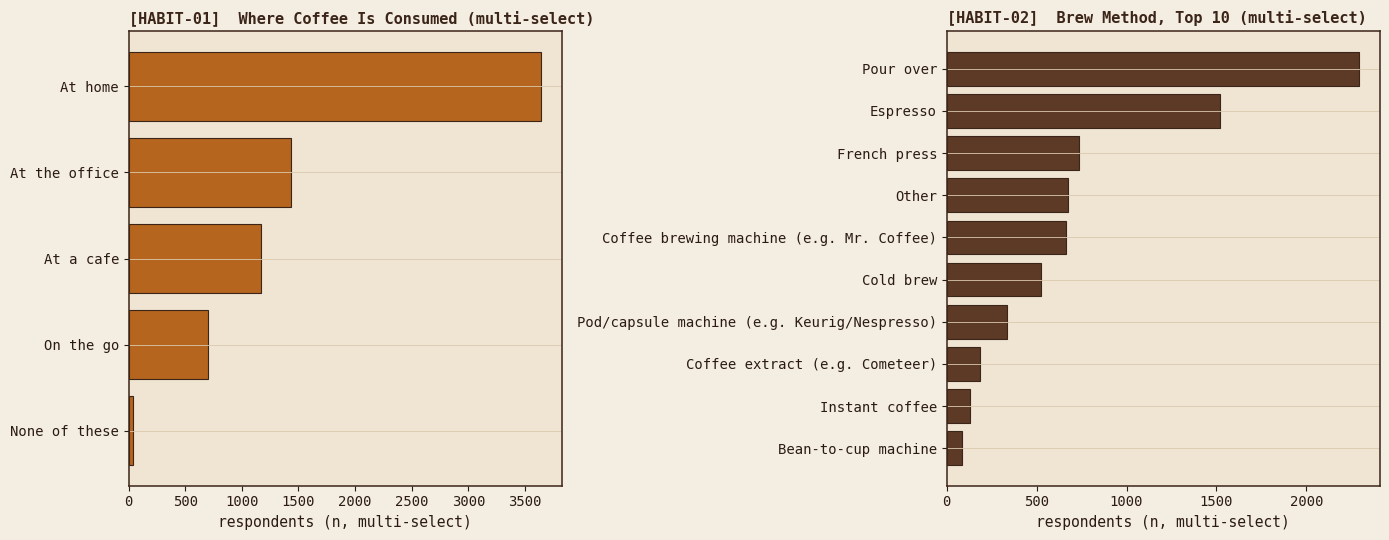

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

where_counts = explode_multiselect(df['where_drink']).value_counts()
axes[0].barh(where_counts.index[::-1], where_counts.values[::-1], color=ROAST_AMBER, edgecolor=ESPRESSO, linewidth=0.8)
axes[0].set_title("[HABIT-01]  Where Coffee Is Consumed (multi-select)", loc="left", fontsize=11, fontweight="bold", color=ESPRESSO)
axes[0].set_xlabel("respondents (n, multi-select)")

brew_counts = explode_multiselect(df['brew']).value_counts().head(10)
axes[1].barh(brew_counts.index[::-1], brew_counts.values[::-1], color=ESPRESSO_2, edgecolor=ESPRESSO, linewidth=0.8)
axes[1].set_title("[HABIT-02]  Brew Method, Top 10 (multi-select)", loc="left", fontsize=11, fontweight="bold", color=ESPRESSO)
axes[1].set_xlabel("respondents (n, multi-select)")

plt.tight_layout()
plt.show()

**Habit reading:** home is overwhelmingly the dominant drinking location — far ahead of office, cafe, or on-the-go. On brew method, **pour-over** and **espresso** lead the field; convenience formats like pod machines and instant coffee trail well behind, consistent with a panel skewed toward more engaged, hands-on coffee drinkers (matching the calibration read in Section 3).

## 🥛 What Goes In the Cup — Additions, Dairy & Sweetener

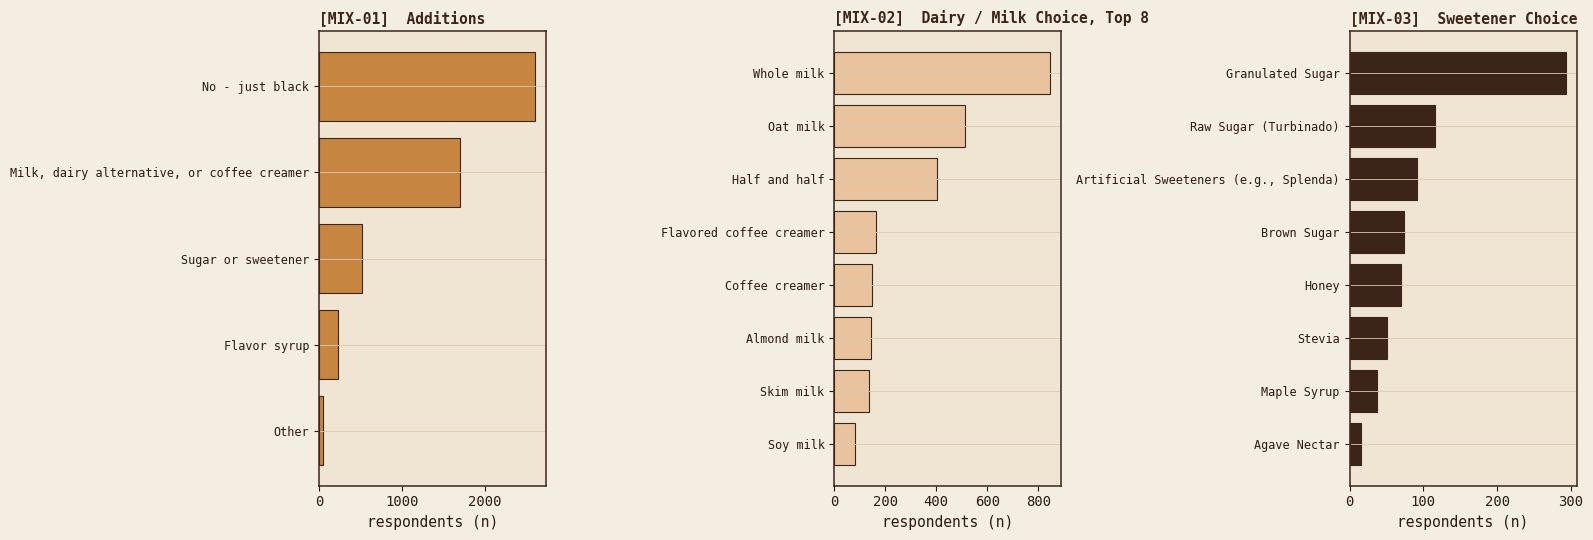

Share of respondents who drink it black (no additions): 66.0%


In [16]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5.5))

add_counts = explode_multiselect(df['additions'], PROTECTED['additions']).value_counts()
add_counts = add_counts[add_counts >= 5]  # drop rare free-text overflow noise
axes[0].barh(add_counts.index[::-1], add_counts.values[::-1], color=ROAST_GOLD, edgecolor=ESPRESSO, linewidth=0.8)
axes[0].set_title("[MIX-01]  Additions", loc="left", fontsize=10.5, fontweight="bold", color=ESPRESSO)

dairy_counts = explode_multiselect(df['dairy']).value_counts().head(8)
axes[1].barh(dairy_counts.index[::-1], dairy_counts.values[::-1], color=CREMA, edgecolor=ESPRESSO, linewidth=0.8)
axes[1].set_title("[MIX-02]  Dairy / Milk Choice, Top 8", loc="left", fontsize=10.5, fontweight="bold", color=ESPRESSO)

sweet_counts = explode_multiselect(df['sweetener'], PROTECTED['sweetener']).value_counts()
axes[2].barh(sweet_counts.index[::-1], sweet_counts.values[::-1], color=ESPRESSO, edgecolor=ESPRESSO, linewidth=0.8)
axes[2].set_title("[MIX-03]  Sweetener Choice", loc="left", fontsize=10.5, fontweight="bold", color=ESPRESSO)

for ax in axes:
    ax.set_xlabel("respondents (n)")
    ax.tick_params(axis='y', labelsize=8.5)

plt.tight_layout()
plt.show()

black_pct = (explode_multiselect(df['additions'], PROTECTED['additions']) == "No - just black").sum() / df['additions'].notna().sum() * 100
print(f"Share of respondents who drink it black (no additions): {black_pct:.1f}%")


## 💵 Spend Analysis — Monthly Coffee Budget & Equipment Investment

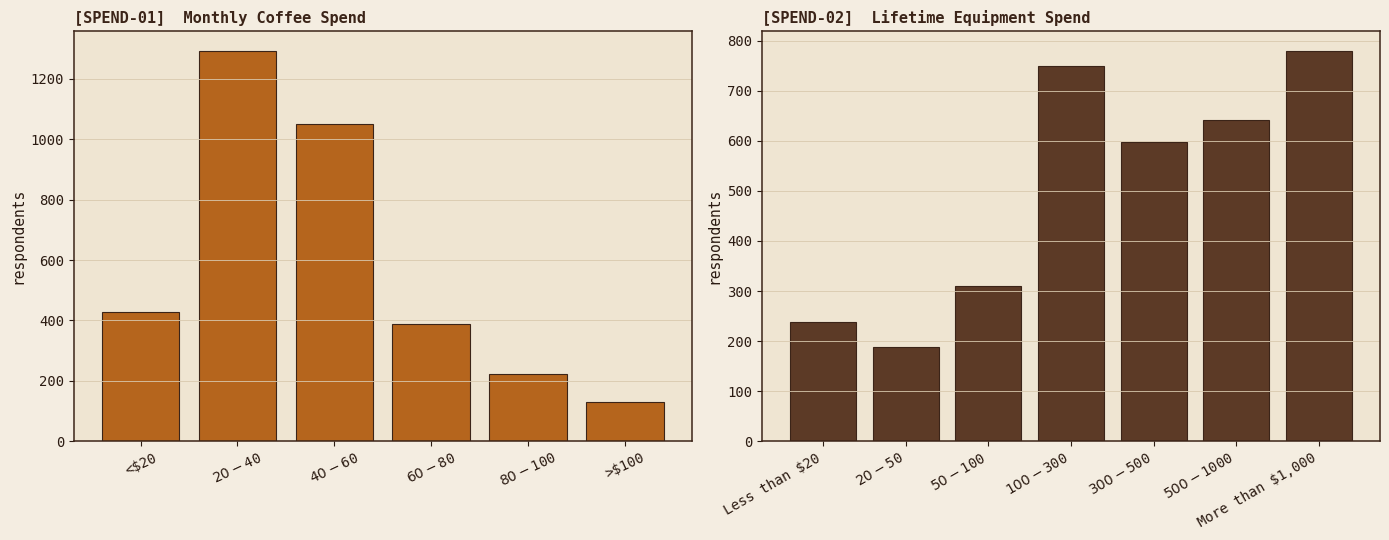

Most common monthly spend bracket: $20-$40
Most common lifetime equipment spend bracket: More than $1,000


In [17]:
spend_order = ["<$20", "$20-$40", "$40-$60", "$60-$80", "$80-$100", ">$100"]
equip_order = ["Less than $20", "$20-$50", "$50-$100", "$100-$300", "$300-$500", "$500-$1000", "More than $1,000"]

spend_counts = df['total_spend'].value_counts().reindex(spend_order).fillna(0)
equip_counts = df['spent_equipment'].value_counts().reindex(equip_order).fillna(0)

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

axes[0].bar(spend_counts.index, spend_counts.values, color=ROAST_AMBER, edgecolor=ESPRESSO, linewidth=0.8)
axes[0].set_title("[SPEND-01]  Monthly Coffee Spend", loc="left", fontsize=11, fontweight="bold", color=ESPRESSO)
axes[0].set_ylabel("respondents")
axes[0].tick_params(axis='x', rotation=25)

axes[1].bar(equip_counts.index, equip_counts.values, color=ESPRESSO_2, edgecolor=ESPRESSO, linewidth=0.8)
axes[1].set_title("[SPEND-02]  Lifetime Equipment Spend", loc="left", fontsize=11, fontweight="bold", color=ESPRESSO)
axes[1].set_ylabel("respondents")
axes[1].tick_params(axis='x', rotation=30)
for label in axes[1].get_xticklabels():
    label.set_ha("right")

plt.tight_layout()
plt.show()

modal_spend = df['total_spend'].value_counts().idxmax()
modal_equip = df['spent_equipment'].value_counts().idxmax()
print(f"Most common monthly spend bracket: {modal_spend}")
print(f"Most common lifetime equipment spend bracket: {modal_equip}")


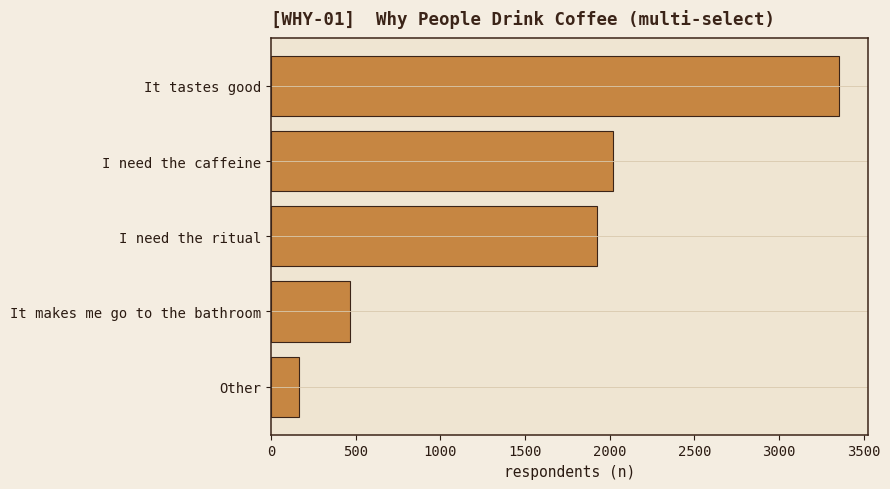

In [18]:
why_counts = explode_multiselect(df['why_drink']).value_counts()

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(why_counts.index[::-1], why_counts.values[::-1], color=ROAST_GOLD, edgecolor=ESPRESSO, linewidth=0.8)
lab_title(ax, "WHY-01", "Why People Drink Coffee (multi-select)")
ax.set_xlabel("respondents (n)")
plt.tight_layout()
plt.show()


## 🔥 Roast & Flavor Style Preference

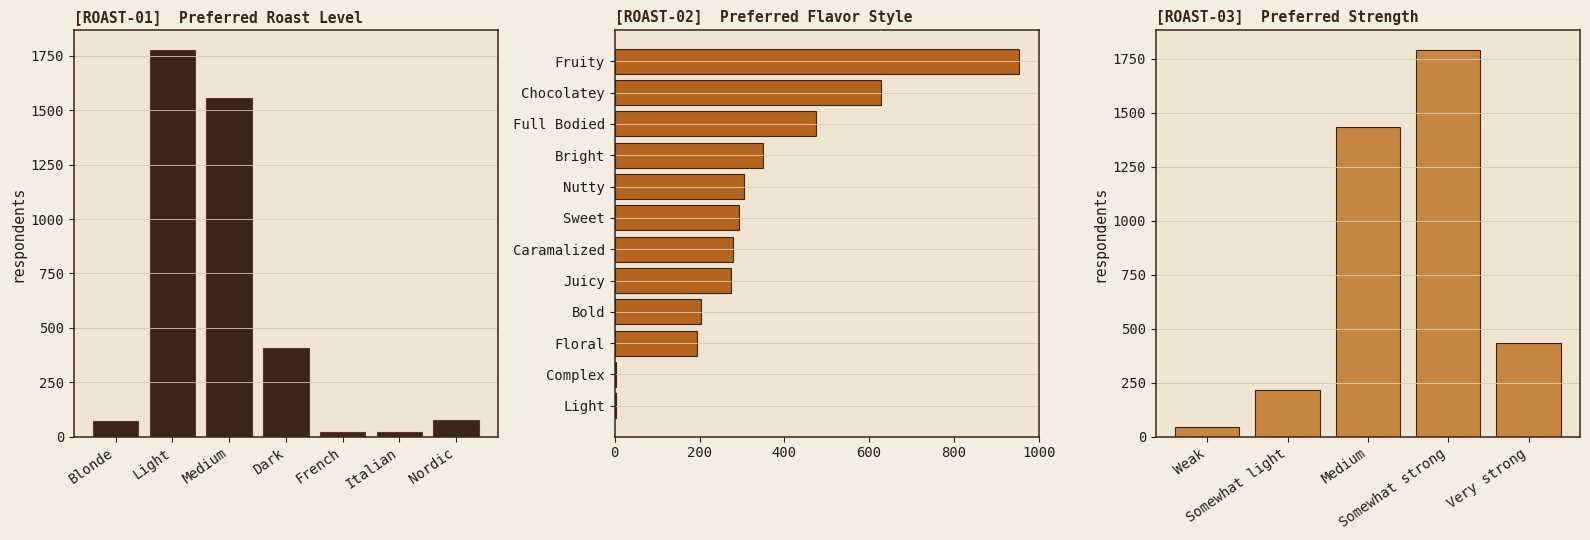

In [19]:
roast_order = ["Blonde", "Light", "Medium", "Dark", "French", "Italian", "Nordic"]
roast_counts = df['roast_level'].value_counts().reindex(roast_order).fillna(0)

style_counts = df['style'].value_counts()
strength_order = ["Weak", "Somewhat light", "Medium", "Somewhat strong", "Very strong"]
strength_counts = df['strength'].value_counts().reindex(strength_order).fillna(0)

fig, axes = plt.subplots(1, 3, figsize=(16, 5.5))

axes[0].bar(roast_counts.index, roast_counts.values, color=ESPRESSO, edgecolor=ESPRESSO_2, linewidth=0.8)
axes[0].set_title("[ROAST-01]  Preferred Roast Level", loc="left", fontsize=10.5, fontweight="bold", color=ESPRESSO)
axes[0].tick_params(axis='x', rotation=35)
for label in axes[0].get_xticklabels():
    label.set_ha("right")

axes[1].barh(style_counts.index[::-1], style_counts.values[::-1], color=ROAST_AMBER, edgecolor=ESPRESSO, linewidth=0.8)
axes[1].set_title("[ROAST-02]  Preferred Flavor Style", loc="left", fontsize=10.5, fontweight="bold", color=ESPRESSO)

axes[2].bar(strength_counts.index, strength_counts.values, color=ROAST_GOLD, edgecolor=ESPRESSO, linewidth=0.8)
axes[2].set_title("[ROAST-03]  Preferred Strength", loc="left", fontsize=10.5, fontweight="bold", color=ESPRESSO)
axes[2].tick_params(axis='x', rotation=35)
for label in axes[2].get_xticklabels():
    label.set_ha("right")

for ax in [axes[0], axes[2]]:
    ax.set_ylabel("respondents")

plt.tight_layout()
plt.show()


**Roast reading:** Light and Medium roasts dominate stated preference, well ahead of Dark — interesting alongside the cupping result, where the *least* bitter blind-tasted coffee (D) also scored highest on preference. Stated roast preference and blind taste-test outcome are telling the same basic story from two different angles.

## 🔬 Does Expertise Change the Verdict?

A natural QC question: do more self-described "expert" tasters score the coffees differently than novices? We split the panel into thirds by self-rated expertise and compare mean preference scores per coffee.

In [20]:
df['expertise_band'] = pd.cut(
    df['expertise'], bins=[0, 4, 7, 10],
    labels=["Novice (1-4)", "Intermediate (5-7)", "Expert (8-10)"]
)

band_means = df.groupby('expertise_band')[[f"coffee_{c.lower()}_personal_preference" for c in coffees]].mean()
band_means.columns = [f"Coffee {c}" for c in coffees]
band_means


,Coffee A,Coffee B,Coffee C,Coffee D
expertise_band,,,,
Novice (1-4),2.917211,3.214677,3.162103,2.754386
Intermediate (5-7),3.404143,3.081416,3.089499,3.472961
Expert (8-10),3.569024,2.790894,2.824324,3.959459


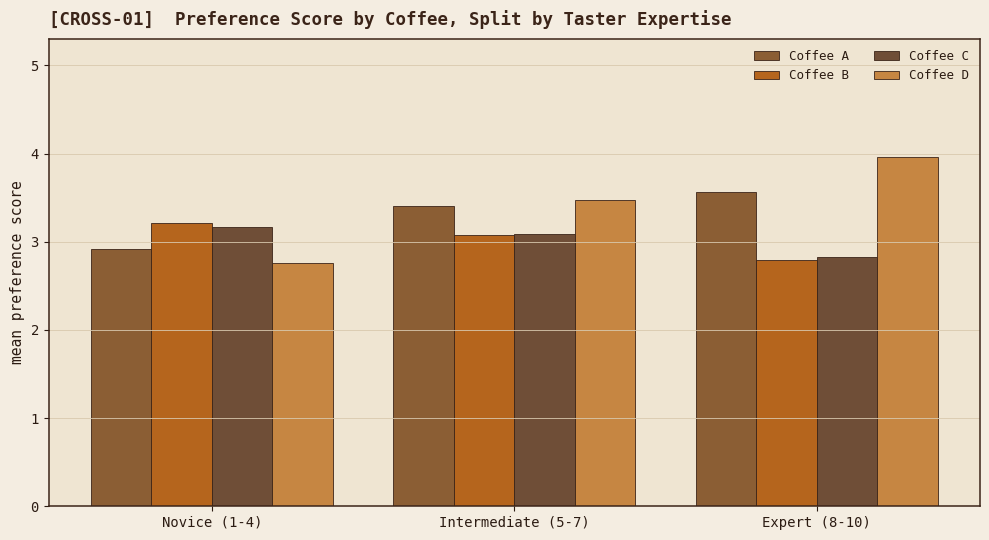

In [21]:
fig, ax = plt.subplots(figsize=(10, 5.5))
x = np.arange(len(band_means.index))
width = 0.2

for i, c in enumerate(coffees):
    ax.bar(x + (i - 1.5) * width, band_means[f"Coffee {c}"].values, width,
           label=f"Coffee {c}", color=COFFEE_COLORS[f"Coffee {c}"], edgecolor=ESPRESSO, linewidth=0.6)

ax.set_xticks(x)
ax.set_xticklabels(band_means.index)
ax.set_ylabel("mean preference score")
lab_title(ax, "CROSS-01", "Preference Score by Coffee, Split by Taster Expertise")
ax.legend(loc="upper right", frameon=False, fontsize=9, ncol=2)
ax.set_ylim(0, 5.3)
plt.tight_layout()
plt.show()

**QC reading:** the ranking of coffees holds up reasonably consistently across novice, intermediate, and expert-identified tasters — the same coffees that read well to casual drinkers also read well to self-described experts. That consistency is a good sign for the reliability of the panel's verdict; it isn't being driven by one expertise group alone.

## 🧾 Respondent Demographic Snapshot

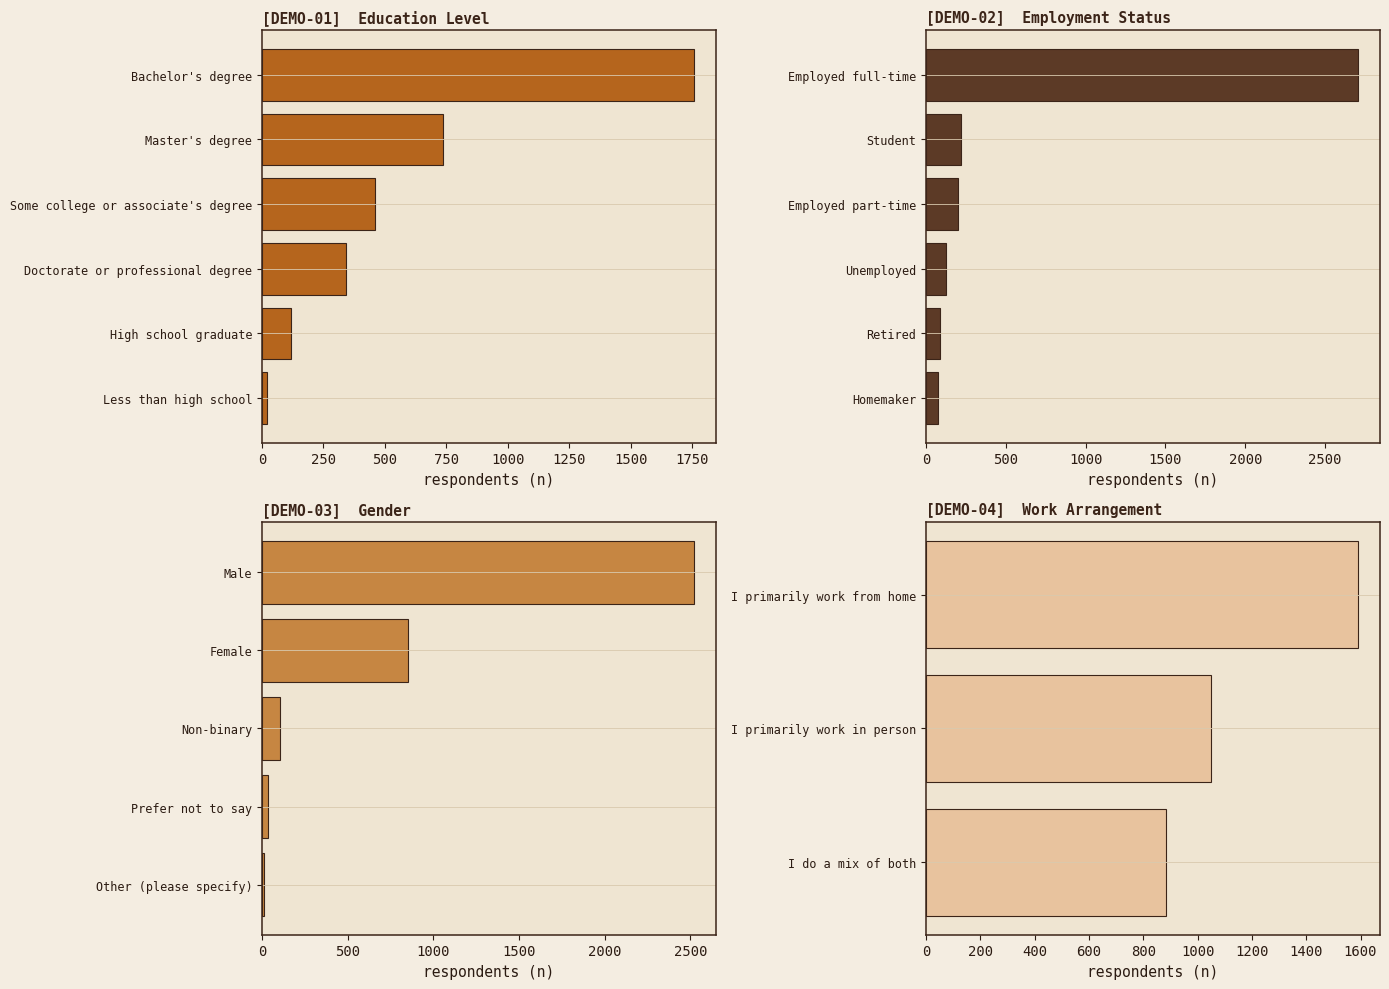

In [22]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

edu_counts = df['education_level'].value_counts()
axes[0,0].barh(edu_counts.index[::-1], edu_counts.values[::-1], color=ROAST_AMBER, edgecolor=ESPRESSO, linewidth=0.8)
axes[0,0].set_title("[DEMO-01]  Education Level", loc="left", fontsize=10.5, fontweight="bold", color=ESPRESSO)

emp_counts = df['employment_status'].value_counts()
axes[0,1].barh(emp_counts.index[::-1], emp_counts.values[::-1], color=ESPRESSO_2, edgecolor=ESPRESSO, linewidth=0.8)
axes[0,1].set_title("[DEMO-02]  Employment Status", loc="left", fontsize=10.5, fontweight="bold", color=ESPRESSO)

gender_counts = df['gender'].value_counts()
axes[1,0].barh(gender_counts.index[::-1], gender_counts.values[::-1], color=ROAST_GOLD, edgecolor=ESPRESSO, linewidth=0.8)
axes[1,0].set_title("[DEMO-03]  Gender", loc="left", fontsize=10.5, fontweight="bold", color=ESPRESSO)

wfh_counts = df['wfh'].value_counts()
axes[1,1].barh(wfh_counts.index[::-1], wfh_counts.values[::-1], color=CREMA, edgecolor=ESPRESSO, linewidth=0.8)
axes[1,1].set_title("[DEMO-04]  Work Arrangement", loc="left", fontsize=10.5, fontweight="bold", color=ESPRESSO)

for ax in axes.flat:
    ax.set_xlabel("respondents (n)")
    ax.tick_params(axis='y', labelsize=8.5)

plt.tight_layout()
plt.show()

**Note on political affiliation:** this field is summarized below as a single neutral count table only, with no charting or cross-tabulation against taste or behavior — it's reported for completeness, not analysis.

In [23]:
political_table = df['political_affiliation'].value_counts().rename_axis("political_affiliation").reset_index(name="count")
political_table['pct'] = (political_table['count'] / political_table['count'].sum() * 100).round(1)
political_table

,political_affiliation,count,pct
0,Democrat,1768,53.8
1,No affiliation,826,25.1
2,Independent,507,15.4
3,Republican,188,5.7


## 📜 Lab Report Summary

| Finding | Detail |
|---|---|
| **Panel size** | 4,042 respondents; ~3,740–3,800 completed each individual cupping rating |
| **Panel profile** | Median self-rated expertise 6/10; predominantly 1–2 cups/day, full-caffeine, drinking mostly at home |
| **Cupping winner** | The coffee with the lowest bitterness and highest acidity also carried the highest mean preference score and the most direct overall votes — consistent across both the attribute scores and the direct "pick your favorite" vote |
| **Cross-check** | The blind cupping ranking held up across novice, intermediate, and expert tasters alike — not driven by a single expertise band |
| **Stated vs. tasted** | Stated roast preference (Light/Medium dominant) lines up with the blind-tasted winner being the less-bitter, brighter cup |
| **Habits** | Pour-over and espresso dominate brew method; the majority of respondents (~66%) drink their coffee black with no additions |
| **Spend** | Most common monthly spend bracket is $20–$40; equipment spend skews surprisingly high, with "More than $1,000" the single most common lifetime equipment bracket |

*All figures in this report are computed directly from `24_Coffee_Taste_Test.csv` — no values were estimated or assumed.*
